### boston_lr.py

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = fetch_california_housing(as_frame=True)
df = data.frame

features = ["MedInc", "AveRooms", "HouseAge"]
X = df[features]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== Without Scaling ===")
print(f"b0 (intercept): {model.intercept_:.4f}")
for name, coef in zip(features, model.coef_):
    print(f"b ({name}): {coef:.4f}")

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\nMAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

max_idx = np.argmax(np.abs(model.coef_))
print(f"\nHighest |coefficient|: {features[max_idx]} ({model.coef_[max_idx]:.4f})")
print(f"-> '{features[max_idx]}' has the strongest linear influence on house price.")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model_s = LinearRegression()
model_s.fit(X_train_s, y_train)
y_pred_s = model_s.predict(X_test_s)

print("\n=== With StandardScaler ===")
print(f"b0 (intercept): {model_s.intercept_:.4f}")
for name, coef in zip(features, model_s.coef_):
    print(f"b ({name}): {coef:.4f}")
print(f"R²:   {r2_score(y_test, y_pred_s):.4f}")


=== Without Scaling ===
b0 (intercept): 0.0173
b (MedInc): 0.4448
b (AveRooms): -0.0281
b (HouseAge): 0.0168

MAE:  0.6033
RMSE: 0.8117
R²:   0.4972

Highest |coefficient|: MedInc (0.4448)
-> 'MedInc' has the strongest linear influence on house price.

=== With StandardScaler ===
b0 (intercept): 2.0719
b (MedInc): 0.8469
b (AveRooms): -0.0672
b (HouseAge): 0.2122
R²:   0.4972


### boston_mlr_garage.py

=== Baseline (4 features) ===
b0: 30.7676
b (crime): -1.2887
b (rooms): 2.8594
b (age): 0.1220
b (distance): -0.8196
R2: -0.9740

=== With Garage (5 features) ===
b0: 31.7432
b (crime): -1.6217
b (rooms): 2.8465
b (age): 0.0973
b (distance): -0.8364
b (garage): 3.7193
R2: 0.1856

Garage coefficient: 3.7193
-> A house WITH a garage is priced ~$3719 higher on average, all else equal.
R2 improved: -0.9740 -> 0.1856


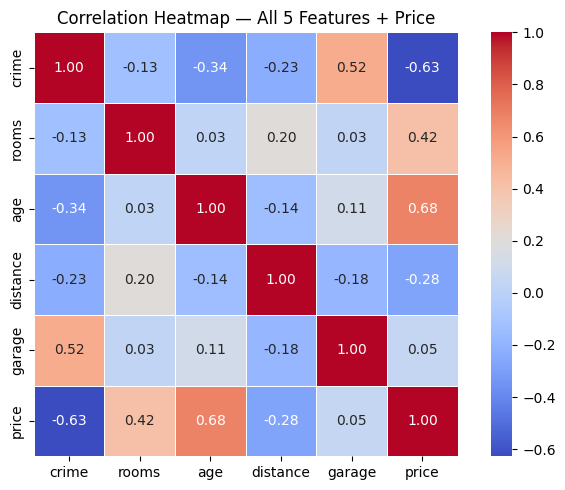

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

np.random.seed(42)
n = 15

crime     = np.round(np.random.uniform(0.1, 10.0, n), 2)
rooms     = np.round(np.random.uniform(4.0, 9.0,  n), 2)
age       = np.round(np.random.uniform(10,  90,   n), 2)
distance  = np.round(np.random.uniform(1.0, 12.0, n), 2)
garage    = np.array([0,1,0,1,1,1,0,1,0,1,0,1,1,0,0])

price = (
    30
    - 1.5 * crime
    + 3.0 * rooms
    + 0.1 * age
    - 0.8 * distance
    + 4.0 * garage
    + np.random.normal(0, 1.5, n)
)
price = np.round(price, 2)

df = pd.DataFrame({
    "crime": crime,
    "rooms": rooms,
    "age": age,
    "distance": distance,
    "garage": garage,
    "price": price
})

features_base  = ["crime", "rooms", "age", "distance"]
features_full  = ["crime", "rooms", "age", "distance", "garage"]

X_base = df[features_base]
X_full = df[features_full]
y      = df["price"]

X_tr_b, X_te_b, y_tr, y_te = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_tr_f, X_te_f, _,    _    = train_test_split(X_full, y, test_size=0.2, random_state=42)

m_base = LinearRegression().fit(X_tr_b, y_tr)
m_full = LinearRegression().fit(X_tr_f, y_tr)

r2_base = r2_score(y_te, m_base.predict(X_te_b))
r2_full = r2_score(y_te, m_full.predict(X_te_f))

print("=== Baseline (4 features) ===")
print(f"b0: {m_base.intercept_:.4f}")
for name, coef in zip(features_base, m_base.coef_):
    print(f"b ({name}): {coef:.4f}")
print(f"R2: {r2_base:.4f}")

print("\n=== With Garage (5 features) ===")
print(f"b0: {m_full.intercept_:.4f}")
for name, coef in zip(features_full, m_full.coef_):
    print(f"b ({name}): {coef:.4f}")
print(f"R2: {r2_full:.4f}")

garage_coef = m_full.coef_[features_full.index("garage")]
print(f"\nGarage coefficient: {garage_coef:.4f}")
print(f"-> A house WITH a garage is priced ~${garage_coef*1000:.0f} higher on average, all else equal.")
print(f"R2 {'improved' if r2_full > r2_base else 'did not improve'}: {r2_base:.4f} -> {r2_full:.4f}")

corr = df[features_full + ["price"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap — All 5 Features + Price")
plt.tight_layout()
plt.savefig("heatmap_garage.png", dpi=150)
plt.show()
